# Skin Disease Advanced - Attention + CV + TTA

- Backbone: Swin-T (Transformer self-attention)
- Strategy: Stratified K-Fold + class-weighted CE + strong augmentation
- Inference: fold ensemble + TTA
- Paths: auto-adapt local and competition platform
- Outputs: always save to `working/submission.csv` (platform) or local output dir


In [1]:
import copy
import gc
import json
import math
import os
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report

from torchvision import models
from torchvision.transforms import v2

print('torch:', torch.__version__)


torch: 2.10.0


In [2]:
# =========================
# Config and paths
# =========================
LOCAL_BASE = Path('/Users/songling/Desktop/Skin Disease Classification')
PLATFORM_BASE = Path('dataset/public')

if PLATFORM_BASE.exists():
    MODE = 'platform'
    BASE_DIR = PLATFORM_BASE
    OUTPUT_DIR = Path('working')
elif LOCAL_BASE.exists():
    MODE = 'local'
    BASE_DIR = LOCAL_BASE
    OUTPUT_DIR = BASE_DIR
else:
    raise FileNotFoundError('Dataset path not found')

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUNS_DIR = OUTPUT_DIR / 'runs'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
run_name = datetime.now().strftime('run_adv_%Y%m%d_%H%M%S')
run_dir = RUNS_DIR / run_name
run_dir.mkdir(parents=True, exist_ok=False)

TRAIN_CSV = BASE_DIR / 'train.csv'
TEST_CSV = BASE_DIR / 'test.csv'
TRAIN_IMG_DIR = BASE_DIR / 'train'
TEST_IMG_DIR = BASE_DIR / 'test'

CLASS_NAMES = ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 16
N_SPLITS = 5
EPOCHS = 18
LR = 2e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
EARLY_STOP_PATIENCE = 5
USE_EMA = True
EMA_DECAY = 0.999

NUM_WORKERS = 0 if MODE == 'local' else 2
PERSISTENT_WORKERS = NUM_WORKERS > 0

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

PIN_MEMORY = (device.type == 'cuda')
USE_AMP = (device.type == 'cuda')

print('Mode      :', MODE)
print('Base dir  :', BASE_DIR)
print('Output dir:', OUTPUT_DIR)
print('Run dir   :', run_dir)
print('Device    :', device)


Mode      : local
Base dir  : /Users/songling/Desktop/Skin Disease Classification
Output dir: /Users/songling/Desktop/Skin Disease Classification
Run dir   : /Users/songling/Desktop/Skin Disease Classification/runs/run_adv_20260220_155304
Device    : mps


In [3]:
# =========================
# Data
# =========================
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

assert set(train_df['disease'].unique()) == set(CLASS_NAMES), 'Unexpected class names'
assert len(test_df) == 180, f'Test rows should be 180, got {len(test_df)}'

train_df['label'] = train_df['disease'].map(label2idx)

class_counts_all = train_df['label'].value_counts().sort_index().values
global_class_weights = len(train_df) / (len(CLASS_NAMES) * class_counts_all)
global_class_weights = torch.tensor(global_class_weights, dtype=torch.float32)
print('Class counts:', dict(zip(CLASS_NAMES, class_counts_all.tolist())))
print('Global class weights:', global_class_weights.numpy())


Class counts: {'acne': 236, 'eksim': 203, 'herpes': 136, 'panu': 103, 'rosacea': 42}
Global class weights: [0.6101695 0.7093596 1.0588236 1.3980583 3.4285715]


In [4]:
# =========================
# Dataset / transforms
# =========================
class AddGaussianNoise(nn.Module):
    def __init__(self, std=0.02, p=0.3):
        super().__init__()
        self.std = std
        self.p = p

    def forward(self, x):
        if torch.rand(1).item() < self.p:
            x = torch.clamp(x + torch.randn_like(x) * self.std, 0.0, 1.0)
        return x

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.15),
    v2.RandomRotation(25),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.04),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    AddGaussianNoise(std=0.02, p=0.25),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

valid_tfms = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class SkinDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.image_dir / row['filename']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        if self.is_test:
            return img, int(row['id'])
        return img, int(row['label'])

def get_loader(ds, shuffle):
    kwargs = dict(batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    if PERSISTENT_WORKERS:
        kwargs['persistent_workers'] = True
    return DataLoader(ds, **kwargs)


In [5]:
# =========================
# Model and train utils
# =========================
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n] = p.data.clone()

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    @torch.no_grad()
    def apply_to(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad:
                p.data.copy_(self.shadow[n])

def build_model():
    m = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
    in_features = m.head.in_features
    m.head = nn.Linear(in_features, len(CLASS_NAMES))

    # Keep attention blocks trainable; optionally freeze patch embedding for regularization
    for n, p in m.named_parameters():
        p.requires_grad = True
    return m.to(device)

def mixup_data(x, y, alpha=0.3):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx, :]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    losses = []
    y_true, y_pred = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        if logits.shape[1] != len(CLASS_NAMES):
            raise RuntimeError(f'Logits dim mismatch: {logits.shape[1]}')

        loss = criterion(logits, labels)
        losses.append(loss.item())

        pred = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(pred.cpu().numpy().tolist())

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    per_class = f1_score(y_true, y_pred, average=None, labels=list(range(len(CLASS_NAMES))))
    return float(np.mean(losses)), macro_f1, np.array(per_class), np.array(y_true), np.array(y_pred)

@torch.no_grad()
def tta_logits(model, images):
    # 4-view TTA: original, hflip, vflip, hvflip
    logits = model(images)
    logits += model(torch.flip(images, dims=[3]))
    logits += model(torch.flip(images, dims=[2]))
    logits += model(torch.flip(images, dims=[2, 3]))
    logits /= 4.0
    return logits



========== Fold 1/5 ==========
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /Users/songling/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:11<00:00, 9.91MB/s] 


Epoch 01/18 | train_loss=1.4771 | val_loss=1.7099 val_macro_f1=0.0168
Epoch 02/18 | train_loss=1.4448 | val_loss=1.7287 val_macro_f1=0.0130
Epoch 03/18 | train_loss=1.4103 | val_loss=1.6160 val_macro_f1=0.0120
Epoch 04/18 | train_loss=1.3016 | val_loss=1.7448 val_macro_f1=0.0090
Epoch 05/18 | train_loss=1.4120 | val_loss=nan val_macro_f1=0.0118
Epoch 06/18 | train_loss=1.3003 | val_loss=1.5107 val_macro_f1=0.0132
Early stopping fold 1 at epoch 6

========== Fold 2/5 ==========


/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 01/18 | train_loss=1.5662 | val_loss=1.6922 val_macro_f1=0.0081


...

Epoch 06/18 | train_loss=1.3814 | val_loss=1.5714 val_macro_f1=0.0149


/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 07/18 | train_loss=1.5113 | val_loss=1.5339 val_macro_f1=0.0115


/Users/songling/Documents/conda/miniconda3/envs/skin_disease_cls/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch 08/18 | train_loss=1.3056 | val_loss=1.5997 val_macro_f1=0.0135
Epoch 09/18 | train_loss=1.5077 | val_loss=1.6851 val_macro_f1=0.0094
Early stopping fold 5 at epoch 9

OOF Macro F1: 0.14406
OOF Classification Report:
              precision    recall  f1-score   support

        acne     0.3191    0.7585    0.4492       236
       eksim     0.1800    0.0443    0.0711       203
      herpes     0.6667    0.0441    0.0828       136
        panu     0.0769    0.0194    0.0310       103
     rosacea     0.0676    0.1190    0.0862        42

    accuracy                         0.2792       720
   macro avg     0.2620    0.1971    0.1441       720
weighted avg     0.2962    0.2792    0.1924       720



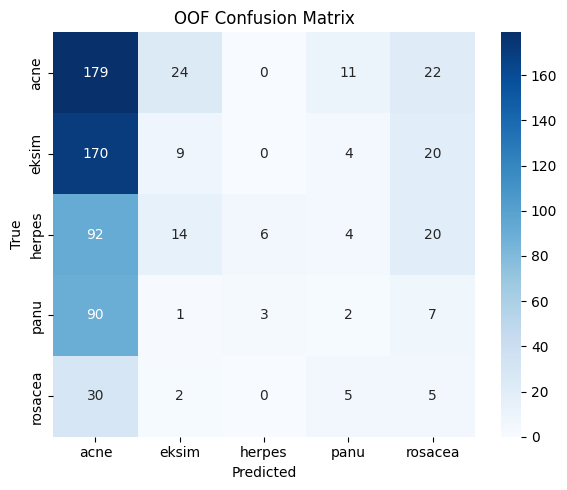

In [6]:
# =========================
# Cross-validation training
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros((len(train_df), len(CLASS_NAMES)), dtype=np.float32)
test_pred = np.zeros((len(test_df), len(CLASS_NAMES)), dtype=np.float32)

fold_metrics = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, train_df['label']), start=1):
    print(f'\n========== Fold {fold}/{N_SPLITS} ==========' )

    tr_df = train_df.iloc[tr_idx].copy()
    va_df = train_df.iloc[va_idx].copy()

    fold_counts = tr_df['label'].value_counts().sort_index().values
    fold_weights = len(tr_df) / (len(CLASS_NAMES) * fold_counts)
    fold_weights = torch.tensor(fold_weights, dtype=torch.float32, device=device)

    train_ds = SkinDataset(tr_df, TRAIN_IMG_DIR, transform=train_tfms, is_test=False)
    valid_ds = SkinDataset(va_df, TRAIN_IMG_DIR, transform=valid_tfms, is_test=False)
    test_ds = SkinDataset(test_df, TEST_IMG_DIR, transform=valid_tfms, is_test=True)

    train_loader = get_loader(train_ds, shuffle=True)
    valid_loader = get_loader(valid_ds, shuffle=False)
    test_loader = get_loader(test_ds, shuffle=False)

    model = build_model()
    criterion = nn.CrossEntropyLoss(weight=fold_weights, label_smoothing=LABEL_SMOOTHING)
    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

    best_f1 = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # MixUp for robustness on small dataset
            images, y_a, y_b, lam = mixup_data(images, labels, alpha=0.3)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(images)
                if logits.shape[1] != len(CLASS_NAMES):
                    raise RuntimeError(f'Logits dim mismatch: {logits.shape[1]}')
                loss = mixup_criterion(criterion, logits, y_a, y_b, lam)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)

            train_losses.append(loss.item())

        scheduler.step()

        # Validate using EMA weights if enabled
        eval_model = copy.deepcopy(model)
        if ema is not None:
            ema.apply_to(eval_model)

        val_loss, val_f1, val_class_f1, y_true, y_pred = evaluate(eval_model, valid_loader, criterion)
        print(
            f'Epoch {epoch:02d}/{EPOCHS} | train_loss={np.mean(train_losses):.4f} | '
            f'val_loss={val_loss:.4f} val_macro_f1={val_f1:.4f}'
        )

        if val_f1 > best_f1:
            best_f1 = val_f1
            bad_epochs = 0
            best_state = copy.deepcopy(eval_model.state_dict())
        else:
            bad_epochs += 1

        del eval_model
        gc.collect()

        if bad_epochs >= EARLY_STOP_PATIENCE:
            print(f'Early stopping fold {fold} at epoch {epoch}')
            break

    # Load best fold model
    model.load_state_dict(best_state)

    # OOF prediction
    model.eval()
    probs_list = []
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device, non_blocking=True)
            logits = tta_logits(model, images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(probs)
    oof_pred[va_idx] = np.concatenate(probs_list, axis=0)

    # Test prediction
    fold_test_probs = []
    with torch.no_grad():
        for images, ids in test_loader:
            images = images.to(device, non_blocking=True)
            logits = tta_logits(model, images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            fold_test_probs.append(probs)

    fold_test_probs = np.concatenate(fold_test_probs, axis=0)
    test_pred += fold_test_probs / N_SPLITS

    fold_metrics.append({'fold': fold, 'best_val_macro_f1': float(best_f1)})
    torch.save(best_state, run_dir / f'swin_t_fold{fold}.pt')

    del model, train_loader, valid_loader, test_loader, train_ds, valid_ds, test_ds
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# OOF metrics
oof_label = train_df['label'].values
oof_pred_label = np.argmax(oof_pred, axis=1)
oof_macro_f1 = f1_score(oof_label, oof_pred_label, average='macro')
print('\nOOF Macro F1:', round(oof_macro_f1, 5))

print('OOF Classification Report:')
print(classification_report(
    oof_label,
    oof_pred_label,
    labels=list(range(len(CLASS_NAMES))),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(oof_label, oof_pred_label, labels=list(range(len(CLASS_NAMES))))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('OOF Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(run_dir / 'oof_confusion_matrix.png', dpi=180)
plt.show()


In [7]:
# =========================
# Submission and artifacts
# =========================
test_label = np.argmax(test_pred, axis=1)
submission = pd.DataFrame({
    'id': test_df['id'].values,
    'disease': [idx2label[int(i)] for i in test_label]
}).sort_values('id').reset_index(drop=True)

assert len(submission) == 180, f'Submission row count must be 180, got {len(submission)}'
assert submission['disease'].isin(CLASS_NAMES).all(), 'Invalid class found in submission'

run_submission_path = run_dir / 'submission.csv'
platform_submission_path = OUTPUT_DIR / 'submission.csv'
submission.to_csv(run_submission_path, index=False)
submission.to_csv(platform_submission_path, index=False)

if MODE == 'local':
    local_submission_path = BASE_DIR / 'submission.csv'
    submission.to_csv(local_submission_path, index=False)

pd.DataFrame(fold_metrics).to_csv(run_dir / 'fold_metrics.csv', index=False)

meta = {
    'run_name': run_name,
    'mode': MODE,
    'base_dir': str(BASE_DIR),
    'output_dir': str(OUTPUT_DIR),
    'device': str(device),
    'n_splits': int(N_SPLITS),
    'epochs': int(EPOCHS),
    'oof_macro_f1': float(oof_macro_f1),
    'fold_metrics': fold_metrics
}
with open(run_dir / 'run_summary.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Run folder        :', run_dir)
print('Run submission    :', run_submission_path)
print('Platform submit   :', platform_submission_path)
if MODE == 'local':
    print('Local copy submit :', local_submission_path)

submission.head()


Run folder        : /Users/songling/Desktop/Skin Disease Classification/runs/run_adv_20260220_155304
Run submission    : /Users/songling/Desktop/Skin Disease Classification/runs/run_adv_20260220_155304/submission.csv
Platform submit   : /Users/songling/Desktop/Skin Disease Classification/submission.csv
Local copy submit : /Users/songling/Desktop/Skin Disease Classification/submission.csv


,id,disease
0,720,acne
1,721,acne
2,722,acne
3,723,acne
4,724,acne
